In [3]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity as ssim, mean_squared_error as mse

# Загрузка изображения

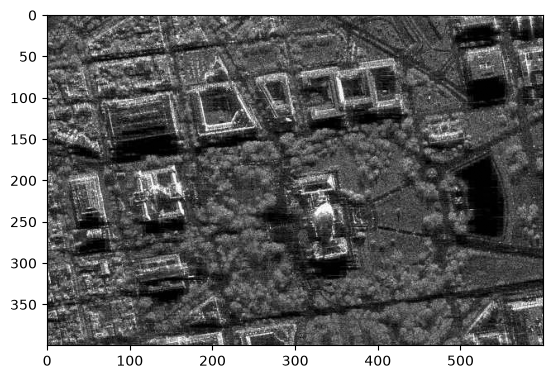

In [4]:
image = cv2.imread("sar_1_gray.jpg", cv2.IMREAD_GRAYSCALE)
plt.imshow(image, cmap="gray")

# Построение гистограммы

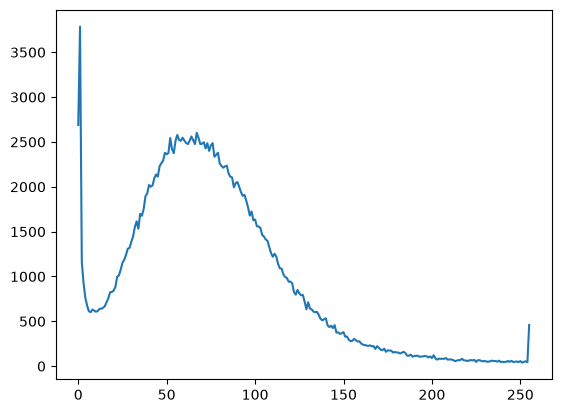

In [5]:
histSize = 256
histRange = (0, 256)
accumulate = False

b_hist = cv2.calcHist([image], [0], None, [histSize], histRange, accumulate=accumulate)

plt.plot(b_hist)

# Алгоритм гамма коррекции

In [6]:
def gamma_correction(image, gamma):
    corrected = np.power(image / 255.0, gamma) * 255
    return corrected.astype(np.uint8)

## Гамма коррекция >1

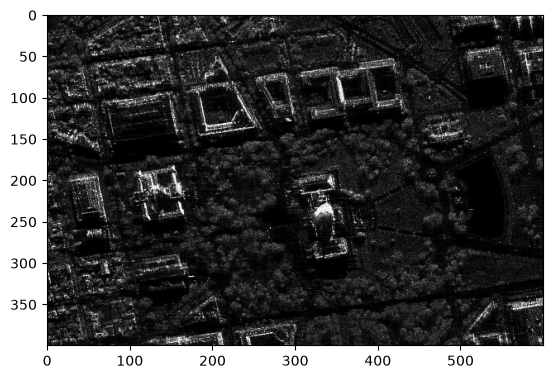

In [17]:
correction_1 = gamma_correction(image, 2)
plt.imshow(correction_1, cmap="gray")

## Гамма коррекция <1

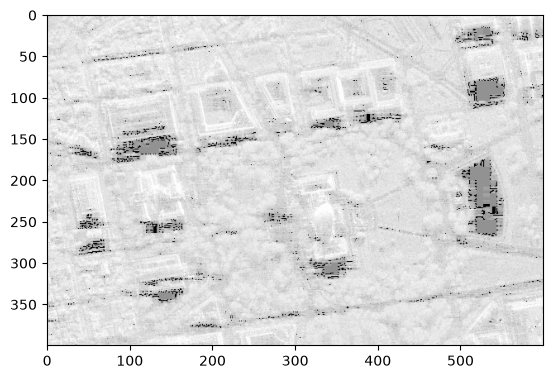

In [8]:
correction_2 = gamma_correction(image, 0.1)
plt.imshow(correction_2, cmap="gray")

# SSIM, MSE

In [9]:
ssim_correction_1 = ssim(image, correction_1)
mse_correction_1 = mse(image, correction_1)

ssim_correction_2 = ssim(image, correction_2)
mse_correction_2 = mse(image, correction_2)

print("MSE correction_1: ", mse_correction_1)
print("SSIM correction_1: ", ssim_correction_1)

print("MSE correction_2: ", mse_correction_2)
print("SSIM correction_2: ", ssim_correction_2)

MSE correction_1:  4424.039683333333
SSIM correction_1:  0.21085324650803924
MSE correction_2:  21665.039608333333
SSIM correction_2:  0.3247689519986237


# Алгоритм статистической цветокоррекции на основе статистики eq_gray

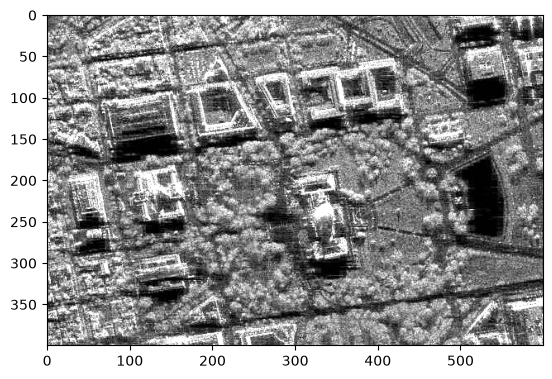

In [10]:
def correction(image, ref):
    mu_s, sd_s = image.mean(), image.std()
    mu_r, sd_r = ref.mean(), ref.std()
    return np.clip((image - mu_s) * (sd_r / sd_s) + mu_r, 0, 255).astype(np.uint8)

eq_gray = cv2.equalizeHist(image)
res = correction(image, eq_gray)


plt.imshow(res, cmap="gray")

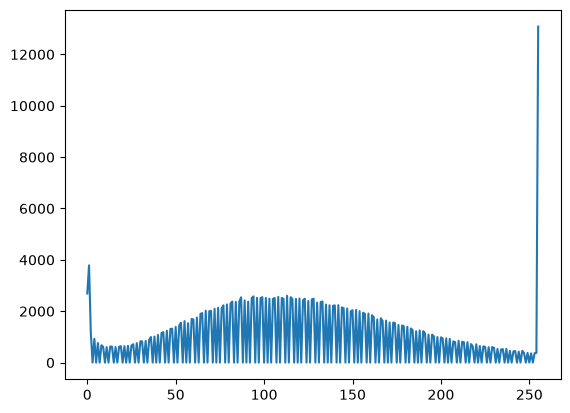

In [11]:
hist = cv2.calcHist([res], [0], None, [histSize], histRange, accumulate=accumulate)
plt.plot(hist)

# Пороговая фильтрация

BINARY, threshold = 50: pixels above threshold = 169178


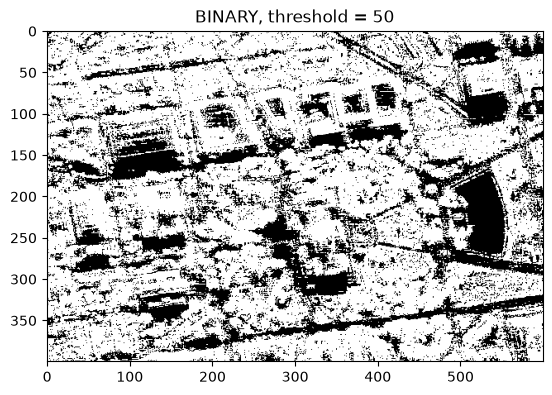

BINARY, threshold = 100: pixels above threshold = 55653


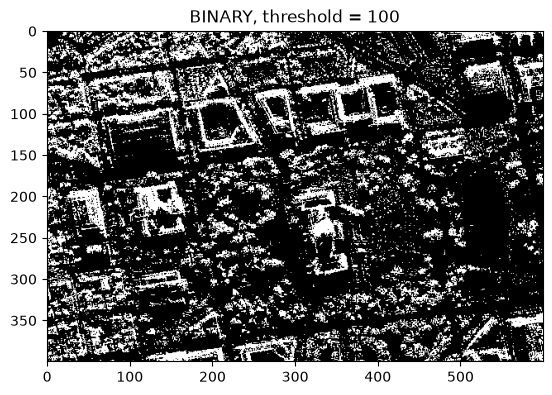

BINARY, threshold = 150: pixels above threshold = 13083


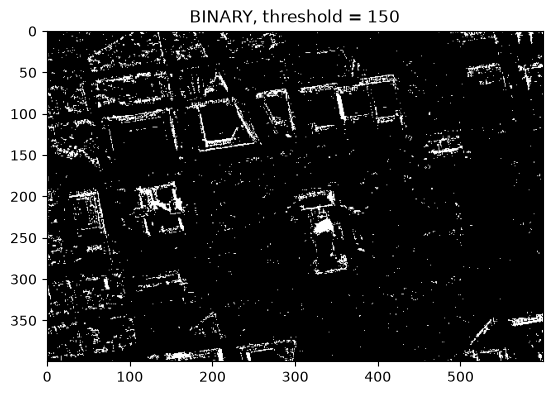

BINARY, threshold = 200: pixels above threshold = 3830


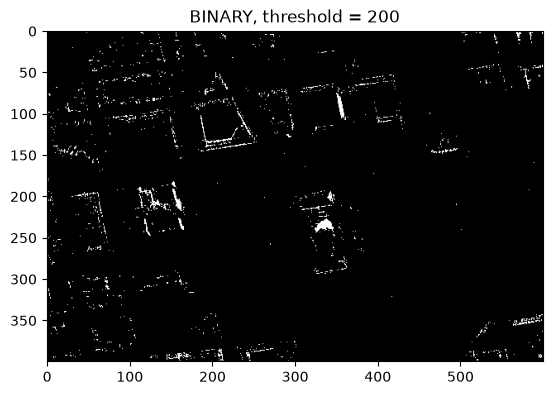

BINARY_INV, threshold = 50: pixels above threshold = 169178


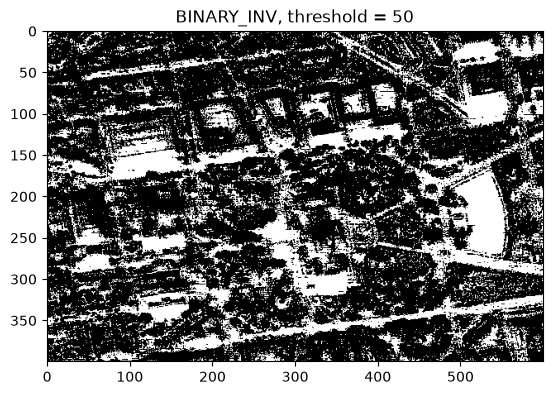

BINARY_INV, threshold = 100: pixels above threshold = 55653


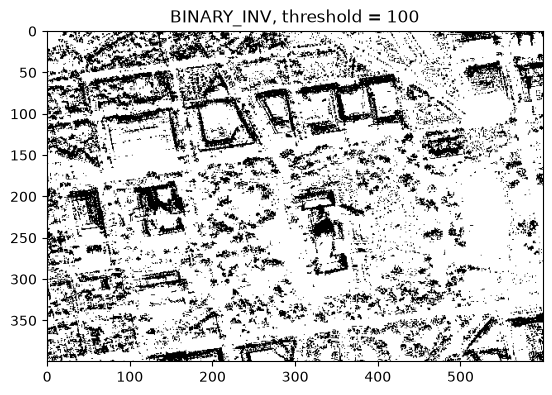

BINARY_INV, threshold = 150: pixels above threshold = 13083


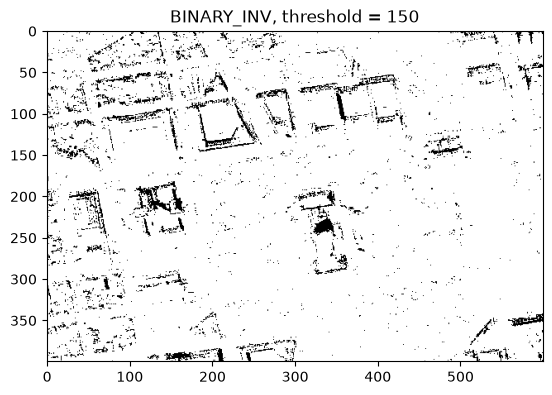

BINARY_INV, threshold = 200: pixels above threshold = 3830


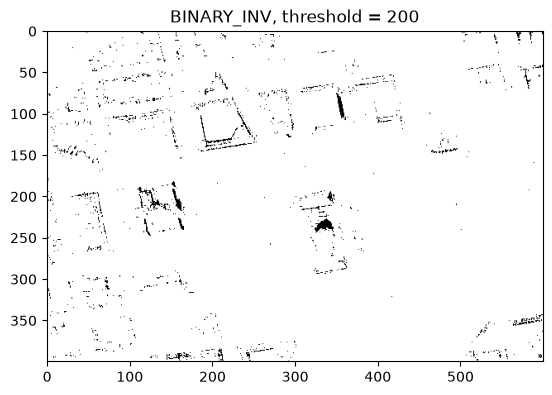

TRUNC, threshold = 50: pixels above threshold = 169178


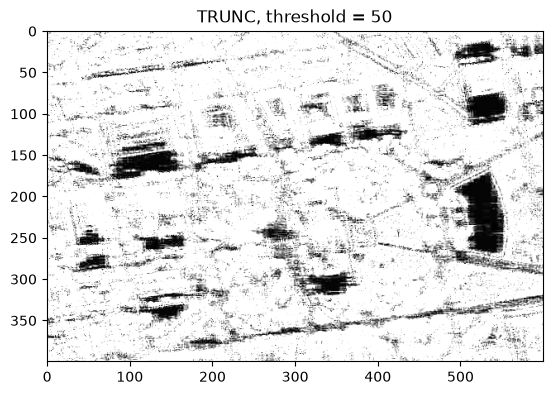

TRUNC, threshold = 100: pixels above threshold = 55653


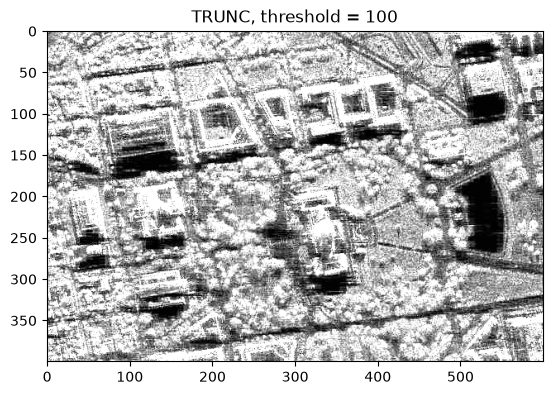

TRUNC, threshold = 150: pixels above threshold = 13083


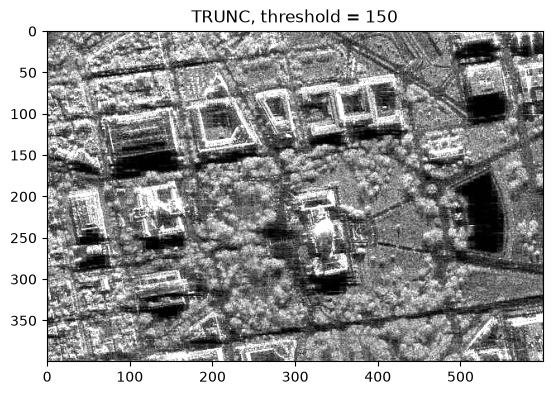

TRUNC, threshold = 200: pixels above threshold = 3830


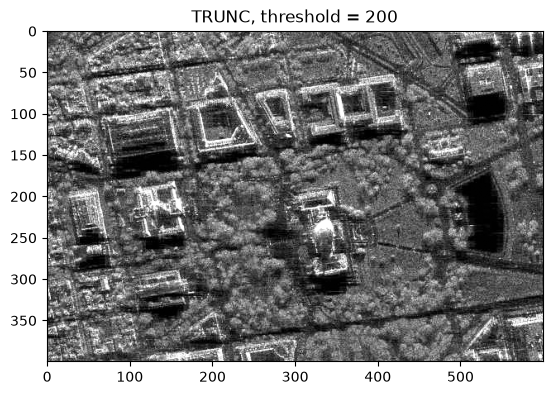

TOZERO, threshold = 50: pixels above threshold = 169178


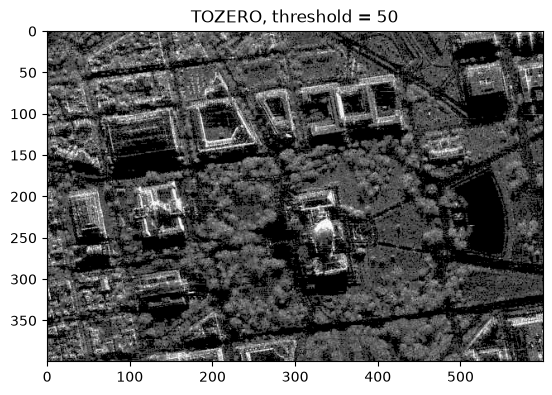

TOZERO, threshold = 100: pixels above threshold = 55653


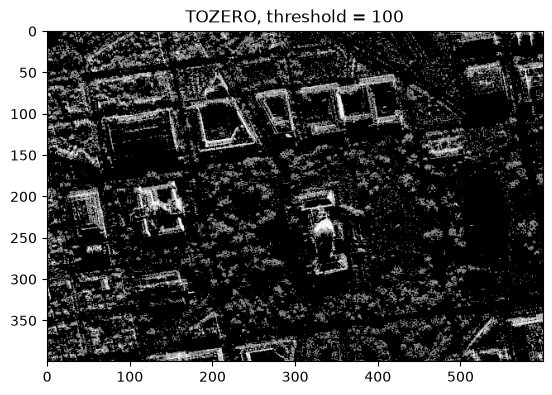

TOZERO, threshold = 150: pixels above threshold = 13083


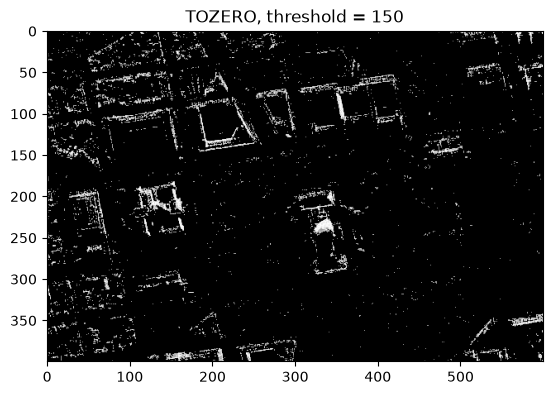

TOZERO, threshold = 200: pixels above threshold = 3830


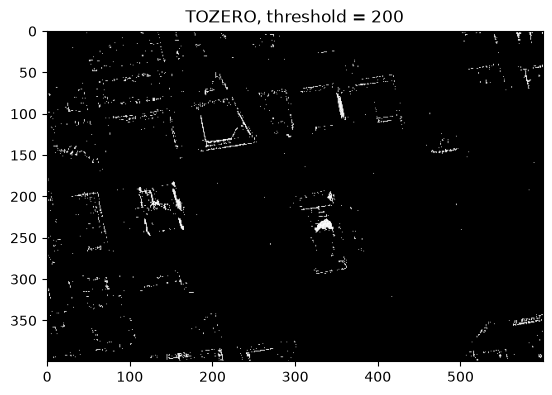

TOZERO_INV, threshold = 50: pixels above threshold = 169178


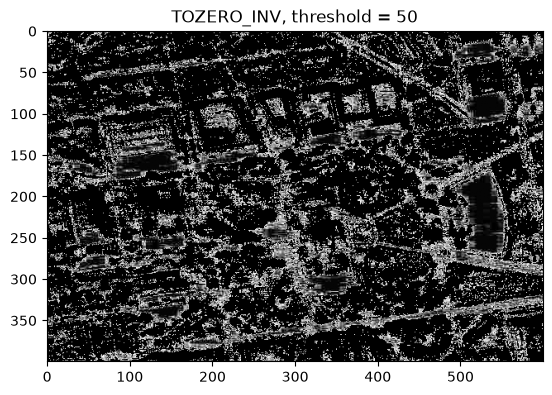

TOZERO_INV, threshold = 100: pixels above threshold = 55653


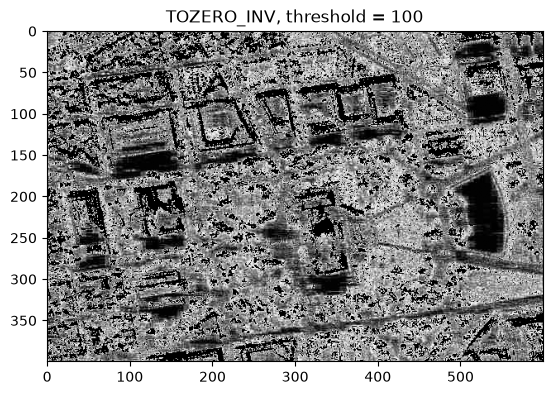

TOZERO_INV, threshold = 150: pixels above threshold = 13083


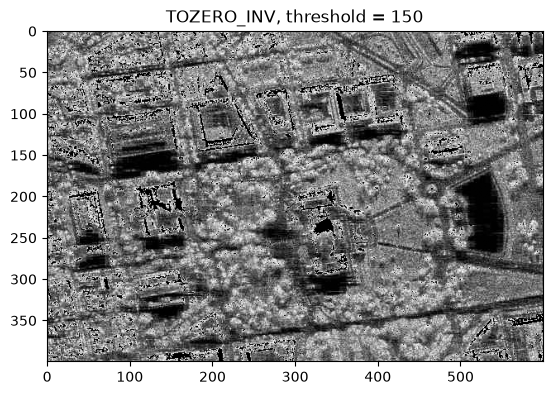

TOZERO_INV, threshold = 200: pixels above threshold = 3830


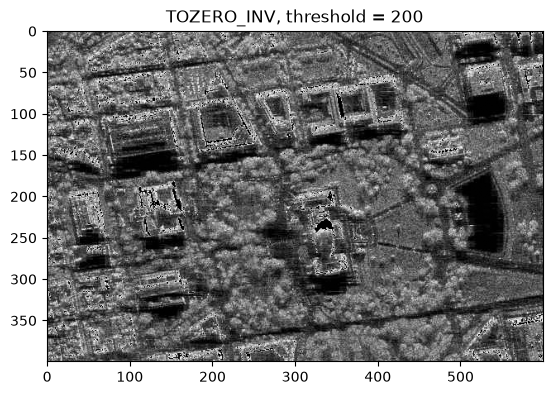

In [16]:
threshold_types = [
    (cv2.THRESH_BINARY,     "BINARY"),
    (cv2.THRESH_BINARY_INV, "BINARY_INV"),
    (cv2.THRESH_TRUNC,      "TRUNC"),
    (cv2.THRESH_TOZERO,     "TOZERO"),
    (cv2.THRESH_TOZERO_INV, "TOZERO_INV"),
]

thresholds = [50, 100, 150, 200]

for ttype, tname in threshold_types:
    for thresh in thresholds:
        _, th = cv2.threshold(image, thresh, 255, ttype)

        # pixels above threshold
        above = int((image > thresh).sum())
        print(f"{tname}, threshold = {thresh}: pixels above threshold = {above}")

        plt.imshow(th, cmap="gray")
        plt.title(f"{tname}, threshold = {thresh}")
        plt.show()